1. Data Exploration:
a. Load the dataset and perform exploratory data analysis (EDA).
b. Examine the features, their types, and summary statistics.
c. Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.
2. Data Preprocessing:
a. Handle missing values (e.g., imputation).
b. Encode categorical variables.
3. Model Building:
a. Build a logistic regression model using appropriate libraries (e.g., scikit-learn).
b. Train the model using the training data.
4. Model Evaluation:
a. Evaluate the performance of the model on the testing data using accuracy, precision, recall, F1-score, and ROC-AUC score.
Visualize the ROC curve.
5. Interpretation:
a. Interpret the coefficients of the logistic regression model.
b. Discuss the significance of features in predicting the target variable (survival probability in this case).
6. Deployment with Streamlit:
In this task, you will deploy your logistic regression model using Streamlit. The deployment can be done locally or online via Streamlit Share. Your task includes creating a Streamlit app in Python that involves loading your trained model and setting up user inputs for predictions. 




In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report
import warnings
warnings.filterwarnings("ignore")

In [2]:
# pip install seaborn

In [3]:
# pip install scikit-learn

In [4]:
data = pd.read_csv("diabetes.csv")  ## reading the dataset
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [5]:
type(data)

pandas.core.frame.DataFrame

In [6]:

data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [8]:
data.sample(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
179,5,130,82,0,0,39.1,0.956,37,1
416,1,97,68,21,0,27.2,1.095,22,0
150,1,136,74,50,204,37.4,0.399,24,0
667,10,111,70,27,0,27.5,0.141,40,1
215,12,151,70,40,271,41.8,0.742,38,1


In [9]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [10]:
data.shape

(768, 9)

In [11]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [12]:
data[data.duplicated()]

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome


In [13]:
data = data.dropna()

In [14]:
data = data.reset_index(drop=True)

In [15]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [16]:
data.drop(["Pregnancies"],axis=1,inplace=True)

In [17]:
data

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,101,76,48,180,32.9,0.171,63,0
764,122,70,27,0,36.8,0.340,27,0
765,121,72,23,112,26.2,0.245,30,0
766,126,60,0,0,30.1,0.349,47,1


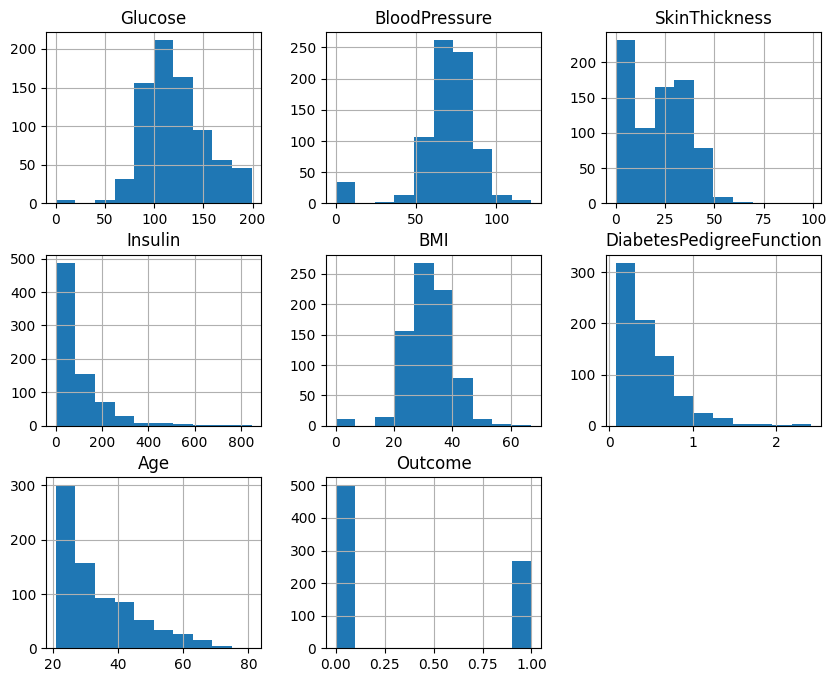

In [18]:
from matplotlib import pyplot as plt


data.hist(figsize=(10,8))
plt.show()

In [19]:
import seaborn as sns

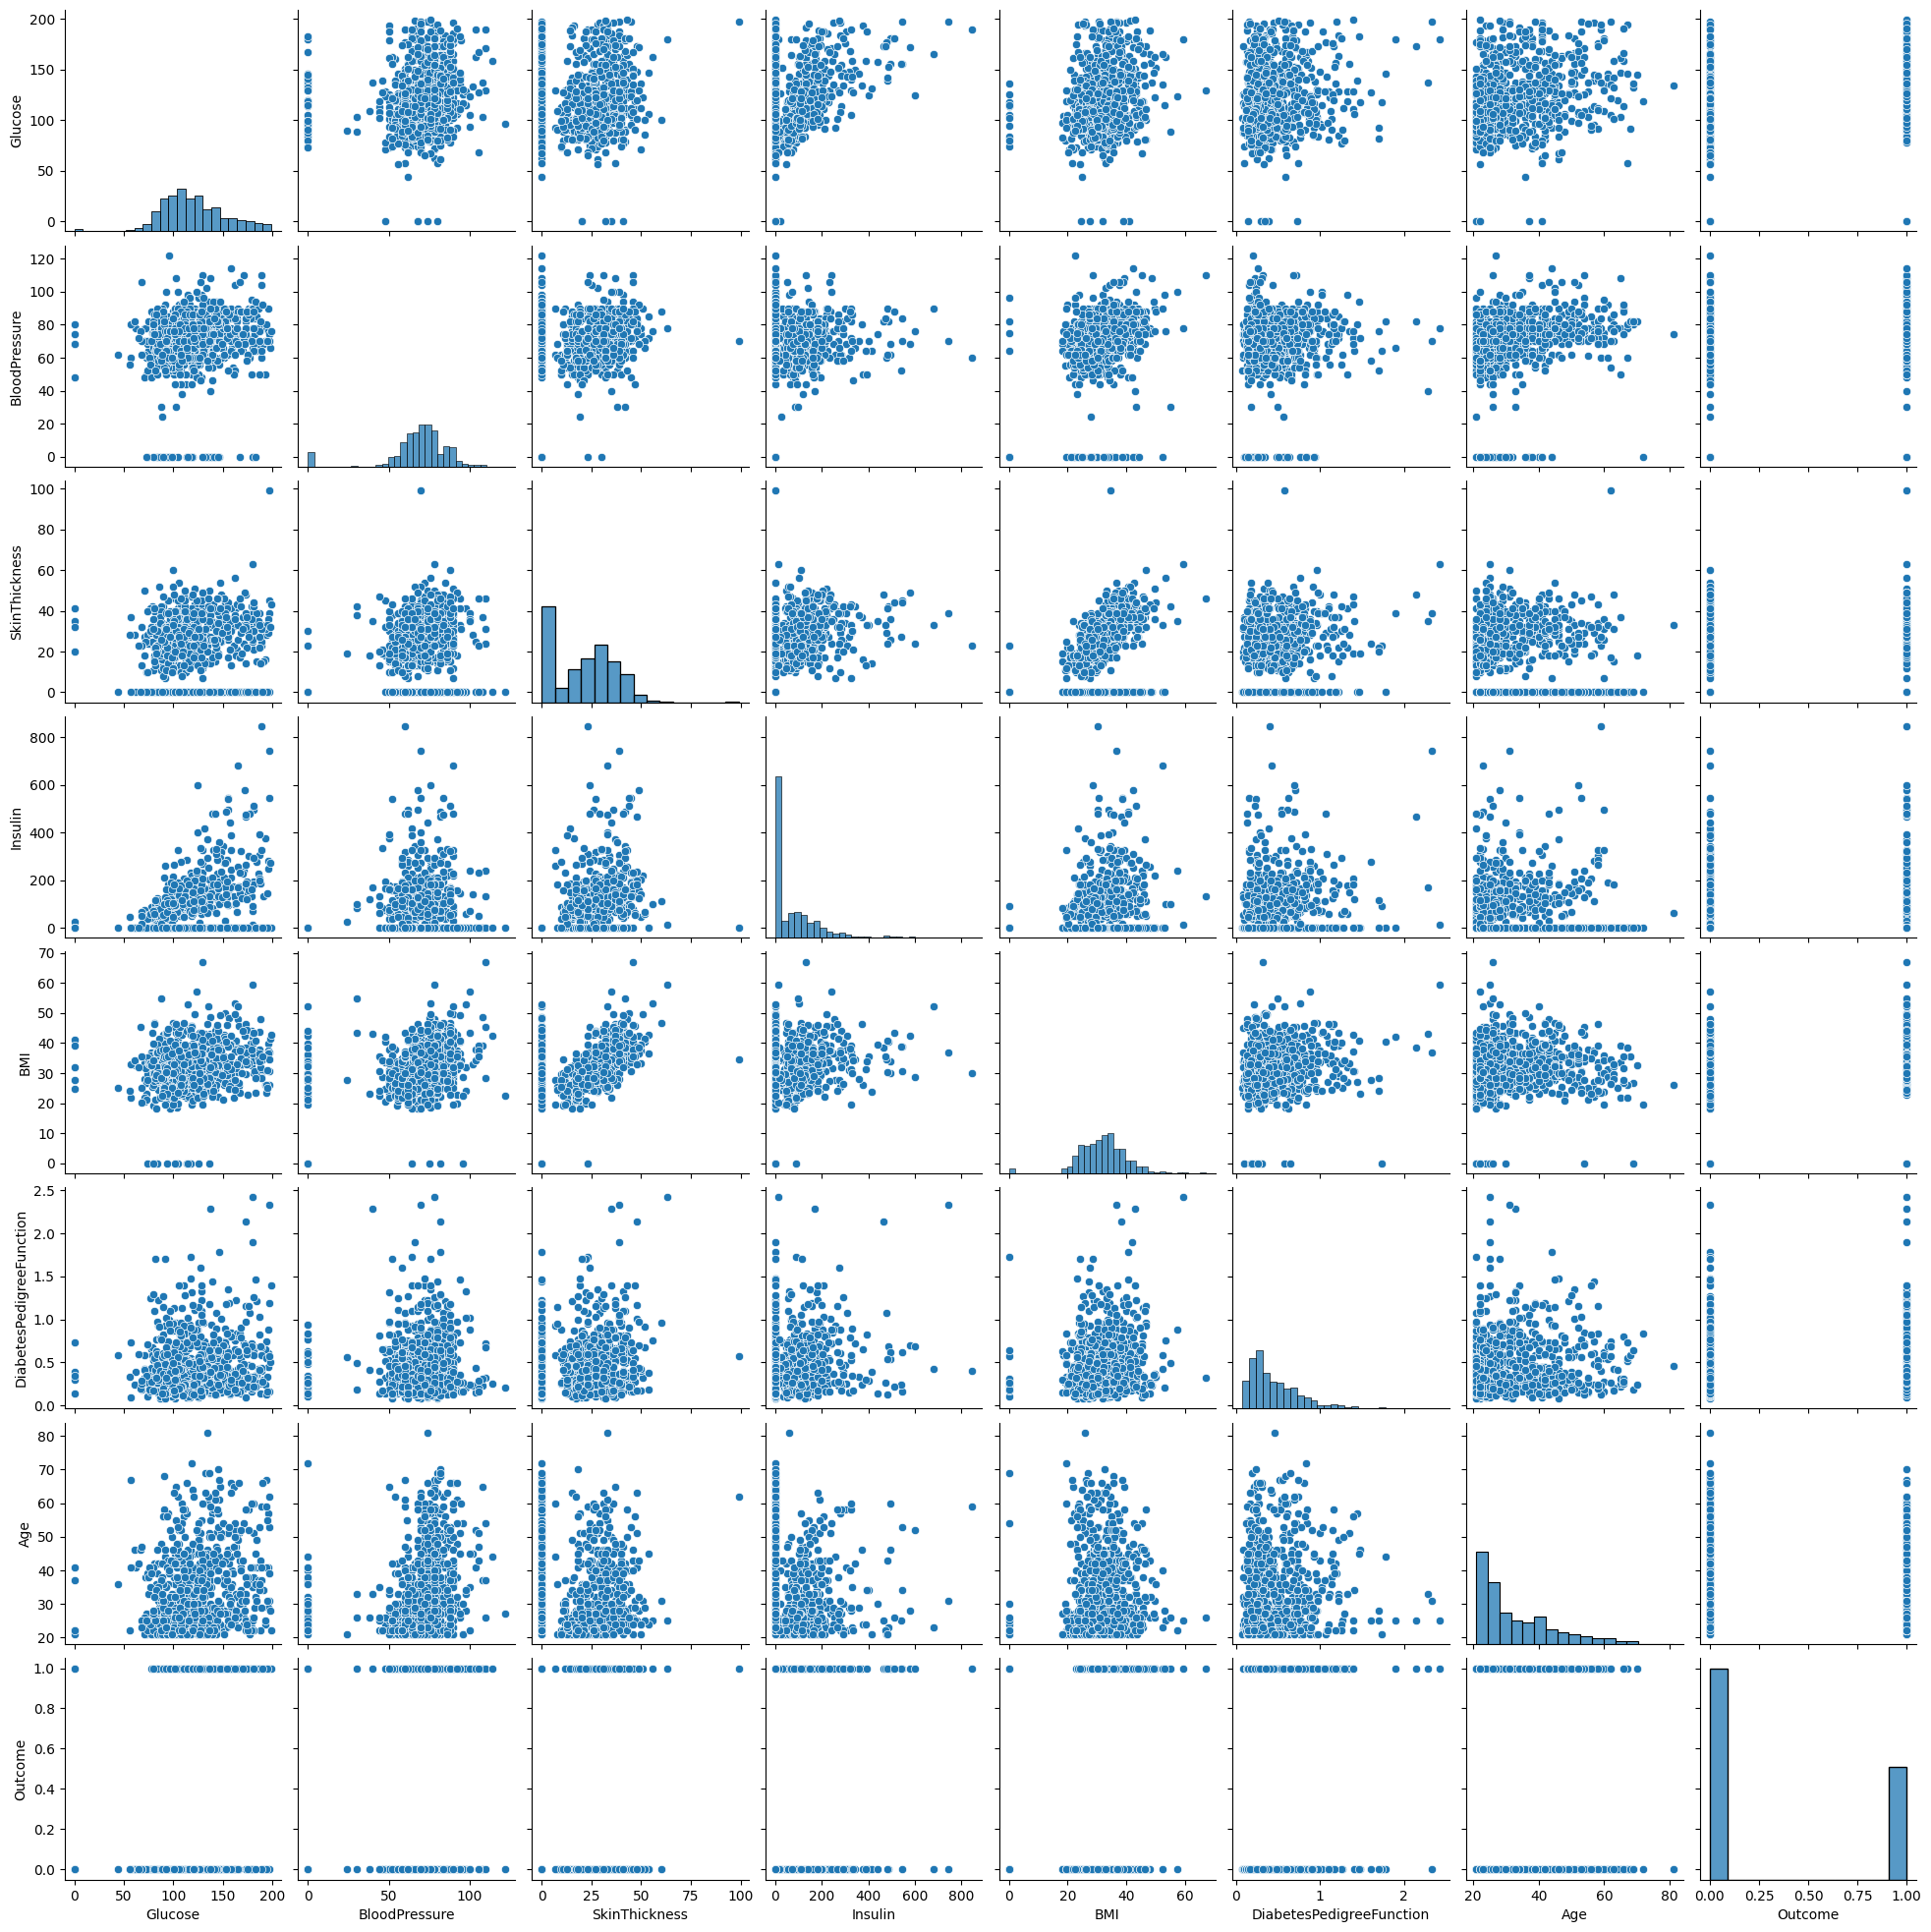

In [20]:
sns.pairplot(data)
plt.show()

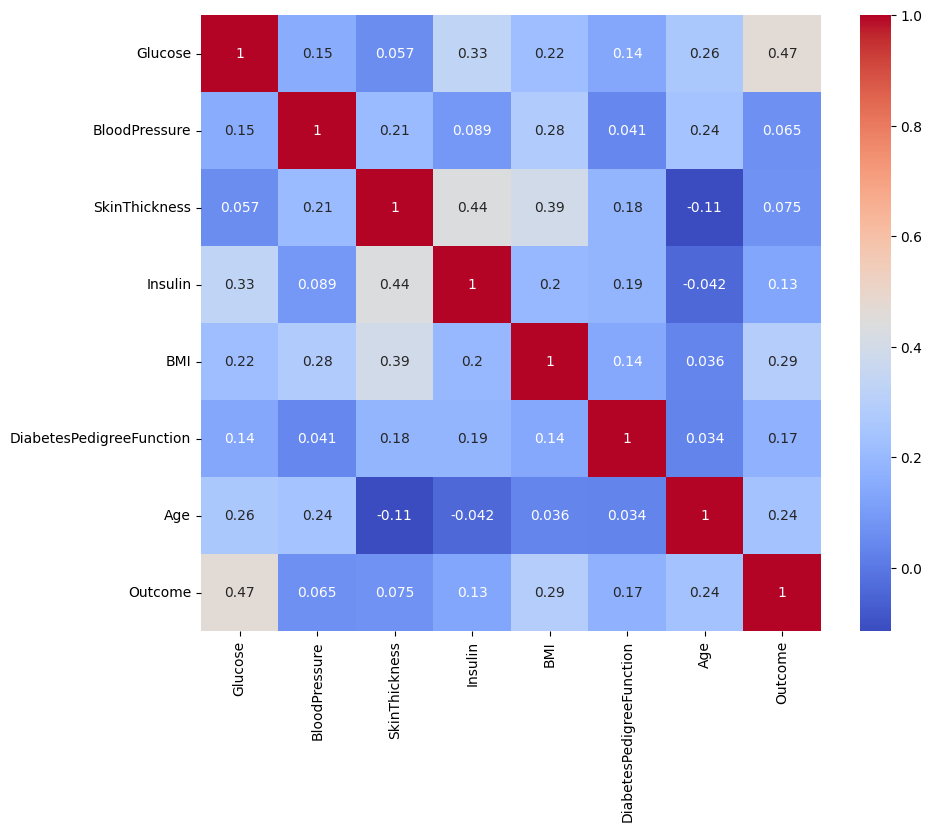

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(),annot=True,cmap="coolwarm")	
plt.show()


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [47]:
X = data.drop(["Outcome"],axis=1)
y = data["Outcome"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [48]:
data

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...
763,101,76,48,180,32.9,0.171,63,0
764,122,70,27,0,36.8,0.340,27,0
765,121,72,23,112,26.2,0.245,30,0
766,126,60,0,0,30.1,0.349,47,1


In [49]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [50]:
from sklearn.metrics	import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve
import	matplotlib.pyplot as plt

In [51]:
y_pred	= model.predict(X_test)
y_pred_prob	= model.predict_proba(X_test)[:, 1]

In [52]:
print("Accuracy:",accuracy_score(y_test, y_pred))

Accuracy: 0.7662337662337663


In [54]:
print("Precision:", precision_score(y_test,y_pred))

Precision: 0.6792452830188679


In [53]:
print("Recall:", recall_score(y_test, y_pred))

Recall: 0.6545454545454545


In [55]:
print("F1-Score:", f1_score(y_test, y_pred))

F1-Score: 0.6666666666666666


In [56]:
print("ROC-AUC Score:", roc_auc_score(y_test,y_pred))

ROC-AUC Score: 0.7414141414141414


In [57]:
# visualaize ROC curve

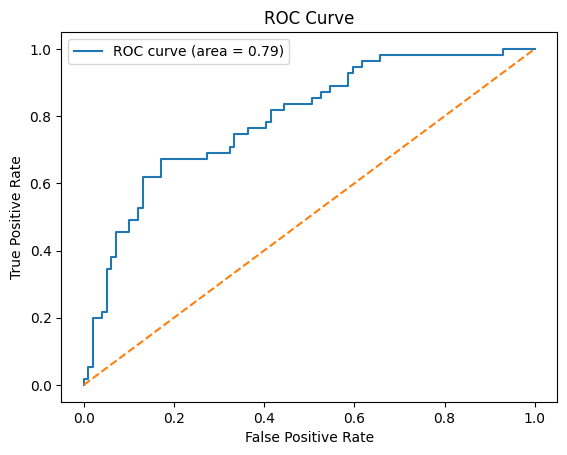

In [58]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc_score(y_test, y_pred_prob):.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


5 a. Interpret Coefficients

In [60]:
coefficients = model.coef_[0]
print(coefficients)

[ 0.03408697 -0.01342738  0.00369206 -0.00193385  0.10212625  0.62463355
  0.04656385]


In [64]:
feature_names = data.drop('Outcome', axis=1).columns
for feature, coef in zip(feature_names, coefficients):
	print(f"{feature}: {coef}")


Glucose: 0.03408697294960126
BloodPressure: -0.01342738224866786
SkinThickness: 0.0036920565040315535
Insulin: -0.0019338497540190445
BMI: 0.10212624698027915
DiabetesPedigreeFunction: 0.6246335532024658
Age: 0.046563845337324085


b. Significance of Features
- Features with larger absolute coefficients have more impact on predicting Outcome.
-Positive coefficients mean the feature increases the likelihood of Outcome=1 (diabetic).
- Negative coefficients mean the feature decreases the likelihood.
 For example, Glucose likely has a significant positive coefficient since high glucose levels are associated with diabetes.


                                  INTERVIEW QUESTIONS

What is the difference between precision and recall?

Precision: It is the ratio of true positives (correctly predicted positive instances) to the sum of true positives and false positives (incorrectly predicted positive instances). It measures how precise the model is when predicting positive instances.

Precision = TP / (TP + FP)

- Recall: It is the ratio of true positives to the sum of true positives and false negatives (missed positive instances). It measures how well the model detects all positive instances.

Recall = TP / (TP + FN)

What is cross-validation, and why is it important in binary classification?

Cross-validation:It is a technique used to evaluate the performance of a model on unseen data. It involves dividing the available data into subsets, training the model on k-1 subsets, and testing it on the remaining subset. This process is repeated k times, and the average performance is calculated.

Why is it important?

1. Reduces overfitting: Cross-validation helps to evaluate the model's performance on unseen data, reducing the risk of overfitting.
2. Improves model selection: It allows you to compare the performance of different models and select the best one.
3. Provides a more accurate estimate of performance: Cross-validation gives a more accurate estimate of the model's performance than a single train-test split.

Types of cross-validation:

1. k-Fold Cross-Validation
2. Stratified k-Fold Cross-Validation (for imbalanced datasets)
3. Leave-One-Out Cross-Validation (LOOCV)